In [64]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline

In [66]:
# Csv dosyasını okur ve df adında bir değişkene atar.

df = pd.read_csv("customer_experience/customer_experience_data.csv")

In [68]:
# Veri setinde bulunan ilk 5 satırı içerikleri ile birlikte verir.

df.head()

,Customer_ID,Age,Gender,Location,Num_Interactions,Feedback_Score,Products_Purchased,Products_Viewed,Time_Spent_on_Site,Satisfaction_Score,Retention_Status,Gender_Encoded,Location_Encoded,Retention_Status_Encoded
0,1,56,Male,Urban,11,4,18,38,18.319606,7,Retained,1,2,1
1,2,69,Male,Suburban,10,3,2,17,9.015198,6,Retained,1,1,1
2,3,46,Male,Urban,5,5,11,46,45.921572,10,Churned,1,2,0
3,4,32,Female,Suburban,5,1,6,13,44.105053,5,Churned,0,1,0
4,5,60,Male,Urban,14,5,8,46,17.897471,1,Retained,1,2,1


In [70]:
# Veri setinin yapısı hakkında bilgi verir.
# Dataset içerisinde kaç satır ve sütun olduğu bilgisini verir.
# Sütunların hangi veri tipinde olduğunun bilgisini verir.
# Eksik veri kontrolü yapıp bilgisini verir.

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer_ID               1000 non-null   int64  
 1   Age                       1000 non-null   int64  
 2   Gender                    1000 non-null   object 
 3   Location                  1000 non-null   object 
 4   Num_Interactions          1000 non-null   int64  
 5   Feedback_Score            1000 non-null   int64  
 6   Products_Purchased        1000 non-null   int64  
 7   Products_Viewed           1000 non-null   int64  
 8   Time_Spent_on_Site        1000 non-null   float64
 9   Satisfaction_Score        1000 non-null   int64  
 10  Retention_Status          1000 non-null   object 
 11  Gender_Encoded            1000 non-null   int64  
 12  Location_Encoded          1000 non-null   int64  
 13  Retention_Status_Encoded  1000 non-null   int64  
dtypes: float6

In [72]:
# Sütundaki her bir değerin kaç defa dataset içerisinde geçtiği bilgisini verir.

df["Satisfaction_Score"].value_counts()

Satisfaction_Score
7     115
2     115
10    106
3      99
9      99
8      98
5      97
6      96
1      96
4      79
Name: count, dtype: int64

In [74]:
# sayısal değişkenlerin ortalama, standart sapma, minimum, maksimum gibi bilgilerini
# hesaplayarak verir.

df.describe()

,Customer_ID,Age,Num_Interactions,Feedback_Score,Products_Purchased,Products_Viewed,Time_Spent_on_Site,Satisfaction_Score,Gender_Encoded,Location_Encoded,Retention_Status_Encoded
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,500.500000,43.81900,7.545000,2.985000,10.417000,27.370000,32.274399,5.540000,0.524000,1.032000,0.69400
std,288.819436,14.99103,4.016978,1.418022,5.345623,12.939572,15.734978,2.904279,0.499674,0.809711,0.46106
min,1.000000,18.00000,1.000000,1.000000,1.000000,5.000000,5.114208,1.000000,0.000000,0.000000,0.00000
25%,250.750000,31.00000,4.000000,2.000000,6.000000,17.000000,18.836771,3.000000,0.000000,0.000000,0.00000
50%,500.500000,44.00000,8.000000,3.000000,11.000000,27.500000,32.455598,6.000000,1.000000,1.000000,1.00000
75%,750.250000,56.00000,11.000000,4.000000,15.000000,38.000000,45.932524,8.000000,1.000000,2.000000,1.00000
max,1000.000000,69.00000,14.000000,5.000000,19.000000,49.000000,59.947722,10.000000,1.000000,2.000000,1.00000


- Yukarıdaki değerlere göre müşterilerin ortalama yaşı 43, en küçük müşterinin yaşı 18 ve en büyük müşterinin yaşı 69' dur.
- Görüntülenen ürün sayısı ortalama 27 iken satın alınan ürün sayısı oralama 10' dur.
- Satisfaction_Score sütunundaki müşterilerin memnuniyet puanlarının dağılımı hakkında genel bir fikir verir. 

In [77]:
# Sütunlara ait medyan değerlerine median() fonksiyonu ile ulaşılabillir.

df["Age"].median()

44.0

In [79]:
df["Products_Viewed"].median()

27.5

In [81]:
df["Products_Purchased"].median()

11.0

In [83]:
df["Satisfaction_Score"].median()

6.0

# Eksik Değer Analizi

In [86]:
# bütün sütunlara ait boş değer kontrolü yapar ve sonuçlarını verir.

df.isnull().sum()

Customer_ID                 0
Age                         0
Gender                      0
Location                    0
Num_Interactions            0
Feedback_Score              0
Products_Purchased          0
Products_Viewed             0
Time_Spent_on_Site          0
Satisfaction_Score          0
Retention_Status            0
Gender_Encoded              0
Location_Encoded            0
Retention_Status_Encoded    0
dtype: int64

Bu dataset' e ait eksik veri bulunmamaktadır.

# Veri Setinde Eksik Değer Olması Durumunda Gerçekleştirilebilecek Eylemler

In [90]:
# Sayısal bir sütundaki eksik veri değerlerin ortalaması ile doldurulur.

# inplace=True parametresi ile df üzerinde kalıcı değişiklik yapılır.

df["Satisfaction_Score"].fillna(df["Satisfaction_Score"].mean(), inplace=True)

In [92]:
# Kategorik bir sütundaki eksik veri, en sık kullanılan veri ile doldurulur.

# mode fonksiyonu, en sık gözlenen değerin bulunması için kullanılır. [0] değerinin 
# alınması mode fonksiyonunun birden fazla değeri seri şeklinde döndürme ihtimaline
# karşın ilk değerin seçilmesini sağlamaktadır.

df["Location"].fillna(df["Location"].mode()[0], inplace=True)

In [94]:
# Eksik değerler doldurulabileceği gibi dataset üzerinden silinedebilir.

# Eksik satırlar tamamen silinebilir.

df_cleaned = df.dropna()

# Sadece belirli sütunlardaki eksikler de silinebilir.

df_cleaned2 = df.dropna(subset=["Gender", "Location"])

In [96]:
# Eksik değerler doldurulabileceği gibi dataset üzerinden silinedebilir.

# Eksik veri içeren sütunlar tamamen silinebilir.

df_cleaned3 = df.dropna(axis=1)

# Sadece belirli satırlar silinebilir.

df_cleaned4 = df.drop(columns=["Customer_ID"])

# Aykırı Değer (Outlier) Analizi

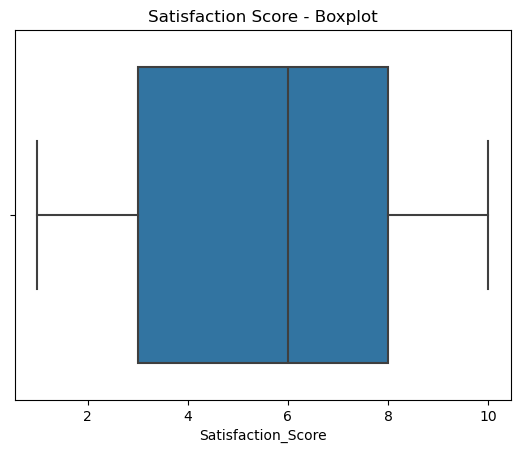

In [99]:
# Boxplot: Aykırı  değerleri tespit etmek için kullanılır.
# Kutunun dışarısında kalan noktalar outlier'dır.

sns.boxplot(x=df["Satisfaction_Score"])
plt.title("Satisfaction Score - Boxplot")
plt.show()

In [101]:
# IQR ile aykırı değerleri tespit etme
# Öncelikle dataset içerisindeki nümerik değerler belirlenir.

numeric_cols = df.select_dtypes(include='number').columns
print("Sayısal sütunlar:", numeric_cols.tolist())

# Her sütun için detaylı IQR bilgisi ve sınırları bir döngü içerisinde yazdırılır.

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR  # katsayı genelde 1.5 olarak alınır
    upper_bound = Q3 + 1.5 * IQR

    min_val = df[col].min()
    max_val = df[col].max()

    print(f"\nSütun: {col}")
    print(f"Q1 (25%): {Q1}")
    print(f"Q3 (75%): {Q3}")
    print(f"IQR: {IQR}")
    print(f"Alt sınır: {lower_bound}")
    print(f"Üst sınır: {upper_bound}")
    print(f"Min değer: {min_val}")
    print(f"Max değer: {max_val}")

    # Bütün hesaplamalar yapıldıktan sonra aykırı değerler belirlenir.
    
    aykiri = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    print(f"Aykırı değer sayısı: {len(aykiri)}")
    if len(aykiri) > 0:
        print(aykiri[[col]])


Sayısal sütunlar: ['Customer_ID', 'Age', 'Num_Interactions', 'Feedback_Score', 'Products_Purchased', 'Products_Viewed', 'Time_Spent_on_Site', 'Satisfaction_Score', 'Gender_Encoded', 'Location_Encoded', 'Retention_Status_Encoded']

Sütun: Customer_ID
Q1 (25%): 250.75
Q3 (75%): 750.25
IQR: 499.5
Alt sınır: -498.5
Üst sınır: 1499.5
Min değer: 1
Max değer: 1000
Aykırı değer sayısı: 0

Sütun: Age
Q1 (25%): 31.0
Q3 (75%): 56.0
IQR: 25.0
Alt sınır: -6.5
Üst sınır: 93.5
Min değer: 18
Max değer: 69
Aykırı değer sayısı: 0

Sütun: Num_Interactions
Q1 (25%): 4.0
Q3 (75%): 11.0
IQR: 7.0
Alt sınır: -6.5
Üst sınır: 21.5
Min değer: 1
Max değer: 14
Aykırı değer sayısı: 0

Sütun: Feedback_Score
Q1 (25%): 2.0
Q3 (75%): 4.0
IQR: 2.0
Alt sınır: -1.0
Üst sınır: 7.0
Min değer: 1
Max değer: 5
Aykırı değer sayısı: 0

Sütun: Products_Purchased
Q1 (25%): 6.0
Q3 (75%): 15.0
IQR: 9.0
Alt sınır: -7.5
Üst sınır: 28.5
Min değer: 1
Max değer: 19
Aykırı değer sayısı: 0

Sütun: Products_Viewed
Q1 (25%): 17.0
Q3 (75%): 3

# Veri Görselleştirme

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


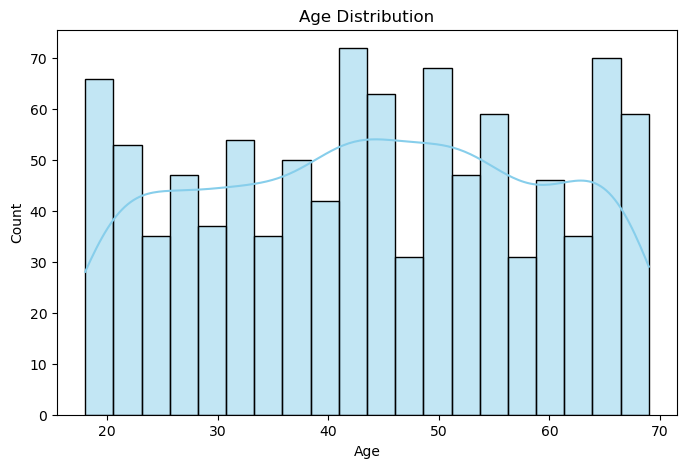

In [104]:
# Sayısal Değişken: Age

plt.figure(figsize=(8,5))
sns.histplot(df["Age"], bins=20, kde=True, color="skyblue")
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

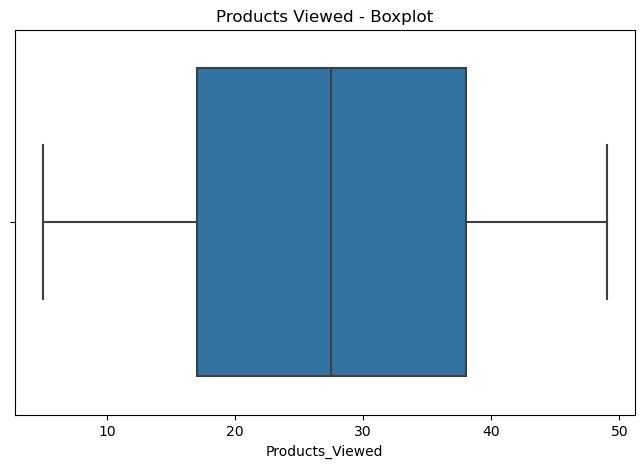

In [106]:
# Sayısal Değişken: Products_Viewed

plt.figure(figsize=(8,5))
sns.boxplot(x=df["Products_Viewed"])
plt.title("Products Viewed - Boxplot")
plt.show()

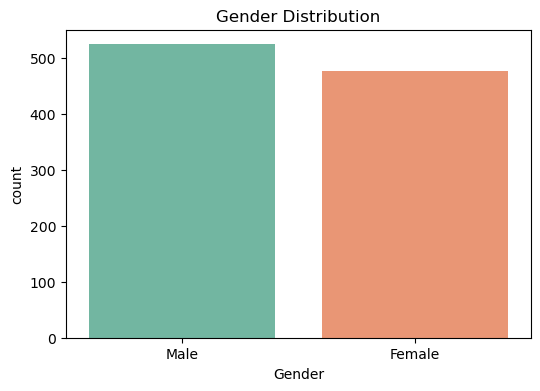

In [108]:
# Kategorik Değişken: Gender

plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Gender", palette="Set2")
plt.title("Gender Distribution")
plt.show()

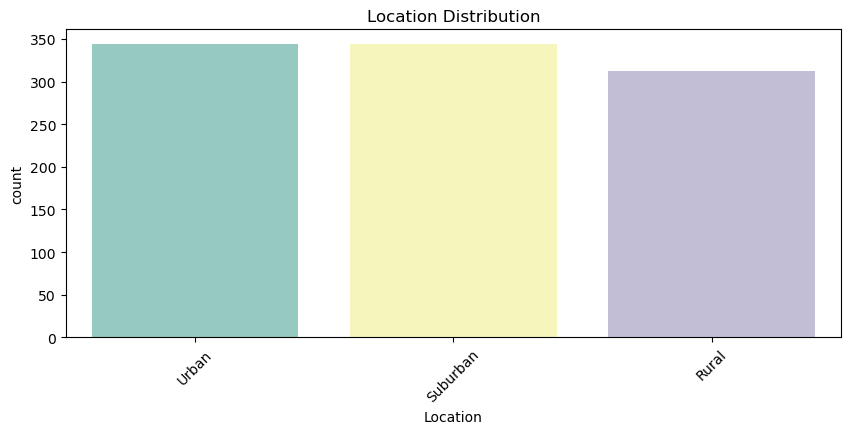

In [110]:
# KAtegorik Değişken: Location

plt.figure(figsize=(10,4))
sns.countplot(data=df, x="Location", palette="Set3",
              order=df["Location"].value_counts().index)
plt.title("Location Distribution")
plt.xticks(rotation=45)
plt.show()

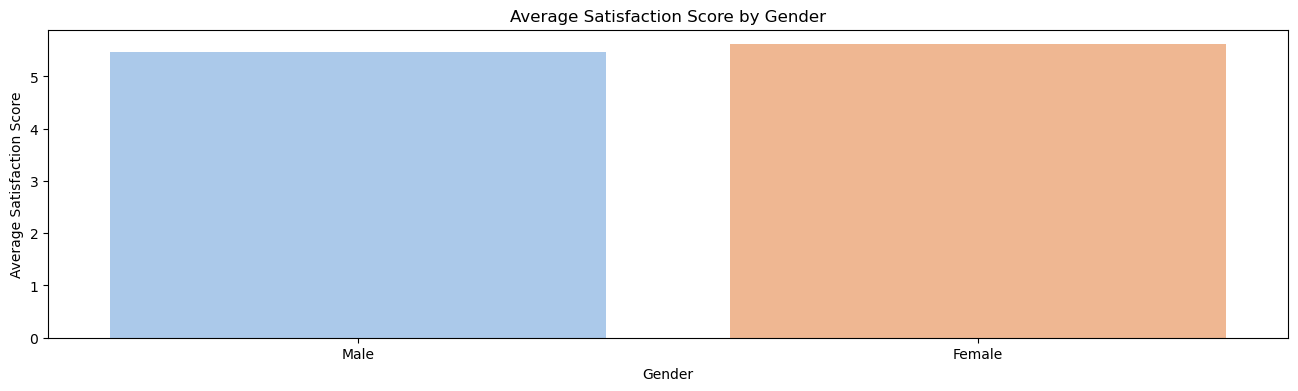

In [112]:
# Kategorik ve Sayısal: Cinsiyete göre ortalama memnuniyet oranı

plt.figure(figsize=(16,4))
sns.barplot(data=df, x="Gender", y="Satisfaction_Score", errorbar=None, palette="pastel")
plt.title("Average Satisfaction Score by Gender")
plt.ylabel("Average Satisfaction Score")
plt.show()

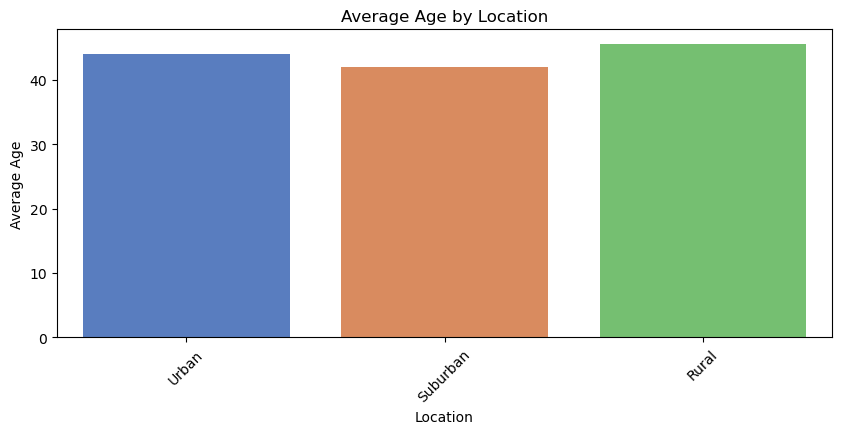

In [114]:
# Kategorik ve Sayısal: Lokasyona göre ortalama yaş

plt.figure(figsize=(10,4))
sns.barplot(data=df, x="Location", y="Age", errorbar=None, palette="muted",
           order=df["Location"].value_counts().index)
plt.title("Average Age by Location")
plt.xticks(rotation=45)
plt.ylabel("Average Age")
plt.show()